# **Project Name** - Named Entity Recognition in Clinical Text Using Domain-Specific BERT

 **Student Name** - Bhanu Prakash Sige

 **Student ID** – A00080352

 **Deep Learning Applications** - (CMP-L016-0)

## Install Required Libraries

In [ ]:
import os

os.system("""
pip install \
  "transformers==4.46.3" \
  "huggingface_hub==0.26.5" \
  "tokenizers==0.20.3" \
  "accelerate==1.1.1" \
  "datasets==2.14.7" \
  evaluate \
  seqeval \
  optuna \
  --no-cache-dir --force-reinstall -q
""")

os.kill(os.getpid(), 9)

## Import Libraries

In [ ]:
import os
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import evaluate
import optuna
import matplotlib.pyplot as plt
from collections import Counter
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    TrainingArguments,
    Trainer,
    DataCollatorForTokenClassification,
    EarlyStoppingCallback
)
from seqeval.metrics import classification_report as seqeval_report
from google.colab import drive

# Silence noisy optuna internal logs — your custom prints still show
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("All imports successful ✅")


All imports successful ✅


In [ ]:
from google.colab import auth
auth.authenticate_user()
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import huggingface_hub, transformers, datasets as ds, accelerate

print(f"huggingface_hub : {huggingface_hub.__version__}")  # expect 0.26.5
print(f"transformers    : {transformers.__version__}")       # expect 4.46.3
print(f"datasets        : {ds.__version__}")                 # expect 2.14.7
print(f"accelerate      : {accelerate.__version__}")         # expect 1.1.1

assert transformers.__version__ == "4.46.3", f"Wrong transformers version: {transformers.__version__}"
print("✅ All versions correct!")


huggingface_hub : 0.26.5
transformers    : 4.46.3
datasets        : 2.14.7
accelerate      : 1.1.1
✅ All versions correct!


## Check GPU Availability

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device    : {device}")
print(f"PyTorch version : {torch.__version__}")

if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")
    vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"VRAM            : {vram_gb:.1f} GB")
    if vram_gb < 20:
        print("⚠️  WARNING: Less than 20 GB VRAM — biobert-large may OOM. Consider biobert-base.")
else:
    raise RuntimeError(
        "No GPU found! Go to Runtime → Change runtime type → GPU (A100) and re-run."
    )


Using device    : cuda
PyTorch version : 2.10.0+cu128
GPU             : NVIDIA A100-SXM4-80GB
VRAM            : 85.1 GB


## Load the NCBI Disease Dataset

The **NCBI Disease corpus** is a benchmark dataset for disease mention recognition in biomedical text. It contains PubMed abstracts annotated with disease entities in **BIO format**:
- `B-Disease` → Beginning of a disease entity
- `I-Disease` → Inside a disease entity
- `O` → Outside any entity


In [ ]:
dataset = load_dataset("ncbi_disease")
print(dataset)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Extracting data files:   0%|          | 0/3 [00:00<?, ?it/s]

Generating train split:   0%|          | 0/5433 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/924 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/941 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'tokens', 'ner_tags'],
        num_rows: 5433
    })
    validation: Dataset({
        features: ['id', 'tokens', 'ner_tags'],
        num_rows: 924
    })
    test: Dataset({
        features: ['id', 'tokens', 'ner_tags'],
        num_rows: 941
    })
})


## Explore Dataset Structure

In [ ]:
sample = dataset['train'][0]
print("\n--- Sample Record ---")
print(f"ID     : {sample['id']}")
print(f"Tokens : {sample['tokens']}")
print(f"NER tags: {sample['ner_tags']}")
print(f"\nSequence length: {len(sample['tokens'])} tokens")

# Check actual sequence length distribution
lengths = [len(s["tokens"]) for s in dataset["train"]]
print(f"\nToken length stats (train):")
print(f"  Max    : {max(lengths)}")
print(f"  Mean   : {sum(lengths)/len(lengths):.1f}")
print(f"  >128   : {sum(1 for l in lengths if l > 128)} samples")
print(f"  >256   : {sum(1 for l in lengths if l > 256)} samples")



--- Sample Record ---
ID     : 0
Tokens : ['Identification', 'of', 'APC2', ',', 'a', 'homologue', 'of', 'the', 'adenomatous', 'polyposis', 'coli', 'tumour', 'suppressor', '.']
NER tags: [0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 2, 2, 0, 0]

Sequence length: 14 tokens

Token length stats (train):
  Max    : 123
  Mean   : 25.0
  >128   : 0 samples
  >256   : 0 samples


## Label Mapping

In [ ]:
label_list = dataset['train'].features['ner_tags'].feature.names
id2label   = {i: label for i, label in enumerate(label_list)}
label2id   = {label: i for i, label in enumerate(label_list)}
num_labels = len(label_list)

print(f"Labels ({num_labels} total): {label_list}")
print(f"\nid2label mapping: {id2label}")


Labels (3 total): ['O', 'B-Disease', 'I-Disease']

id2label mapping: {0: 'O', 1: 'B-Disease', 2: 'I-Disease'}


## Dataset Statistics

In [ ]:
print("Label distribution across splits:\n")
for split in ["train", "validation", "test"]:
    all_tags   = [tag for sample in dataset[split] for tag in sample["ner_tags"]]
    tag_counts = Counter(all_tags)
    total      = len(all_tags)
    print(f"  --- {split.upper()} ({len(dataset[split])} sentences, {total} tokens) ---")
    for tag_id, count in sorted(tag_counts.items()):
        pct = count / total * 100
        print(f"    {id2label[tag_id]:12s} (id={tag_id}): {count:6d}  ({pct:.1f}%)")
    print()


Label distribution across splits:

  --- TRAIN (5433 sentences, 136086 tokens) ---
    O            (id=0): 124819  (91.7%)
    B-Disease    (id=1):   5145  (3.8%)
    I-Disease    (id=2):   6122  (4.5%)

  --- VALIDATION (924 sentences, 23969 tokens) ---
    O            (id=0):  22092  (92.2%)
    B-Disease    (id=1):    787  (3.3%)
    I-Disease    (id=2):   1090  (4.5%)

  --- TEST (941 sentences, 24497 tokens) ---
    O            (id=0):  22450  (91.6%)
    B-Disease    (id=1):    960  (3.9%)
    I-Disease    (id=2):   1087  (4.4%)



## Visualize a Sample with Entity Labels

In [ ]:
def display_ner_sample(sample, id2label):
    """Display tokens with their NER labels side by side."""
    print(f"{'Token':<25} {'Label'}")
    print("-" * 40)
    for token, tag_id in zip(sample['tokens'], sample['ner_tags']):
        label  = id2label[tag_id]
        marker = "  <<< ENTITY" if label != 'O' else ""
        print(f"{token:<25} {label}{marker}")

for sample in dataset['train']:
    if any(tag != 0 for tag in sample['ner_tags']):
        display_ner_sample(sample, id2label)
        break


Token                     Label
----------------------------------------
Identification            O
of                        O
APC2                      O
,                         O
a                         O
homologue                 O
of                        O
the                       O
adenomatous               B-Disease  <<< ENTITY
polyposis                 I-Disease  <<< ENTITY
coli                      I-Disease  <<< ENTITY
tumour                    I-Disease  <<< ENTITY
suppressor                O
.                         O


## Load BioBERT Tokenizer

We use **dmis-lab/biobert-large-cased-v1.1** — the large variant of BioBERT pre-trained on:
- PubMed abstracts (~4.5B words)
- PubMed Central full-text articles (~13.5B words)

Running on A100 (40 GB VRAM) so the large model fits comfortably.


In [ ]:
MODEL_CHECKPOINT = "dmis-lab/biobert-large-cased-v1.1"

tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)
tokenizer.model_max_length = 512

print(f"Tokenizer loaded : {MODEL_CHECKPOINT}")
print(f"Vocab size       : {tokenizer.vocab_size}")
print(f"Max token length : {tokenizer.model_max_length}")

test_sentence = "The patient was diagnosed with Huntington disease and cognitive impairment."
tokens = tokenizer.tokenize(test_sentence)
print(f"\nExample tokenization:")
print(f"Input : {test_sentence}")
print(f"Tokens: {tokens}")


config.json:   0%|          | 0.00/289 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Tokenizer loaded : dmis-lab/biobert-large-cased-v1.1
Vocab size       : 58996
Max token length : 512

Example tokenization:
Input : The patient was diagnosed with Huntington disease and cognitive impairment.
Tokens: ['the', 'patient', 'was', 'diagnosed', 'with', 'hunting', '##ton', 'disease', 'and', 'cognitive', 'imp', '##air', '##ment', '.']


## Tokenization with Label Alignment

**Key Challenge:** BERT uses WordPiece tokenization, which splits words into subword tokens.
For example, `"Huntington"` → `["Hunt", "##ington"]`.

We need to align NER labels to these subword tokens:
- First subword of a word → gets the word's original label
- Subsequent subwords → get label `-100` (ignored during loss computation)
- Special tokens `[CLS]`, `[SEP]` → get label `-100`

`max_length=256` is used (up from 128) to avoid truncating long biomedical abstracts.


In [ ]:
MAX_LENGTH = 256   # increased from 128 — covers virtually all NCBI abstracts

def tokenize_and_align_labels(examples, label_all_tokens=False):
    tokenized_inputs = tokenizer(
        examples["tokens"],
        truncation=True,
        is_split_into_words=True,
        padding='max_length',
        max_length=MAX_LENGTH
    )

    labels = []
    for i, label in enumerate(examples['ner_tags']):
        word_ids         = tokenized_inputs.word_ids(batch_index=i)
        previous_word_idx = None
        label_ids        = []

        for word_idx in word_ids:
            if word_idx is None:
                label_ids.append(-100)
            elif word_idx != previous_word_idx:
                label_ids.append(label[word_idx])
            else:
                label_ids.append(label[word_idx] if label_all_tokens else -100)
            previous_word_idx = word_idx

        labels.append(label_ids)

    tokenized_inputs['labels'] = labels
    return tokenized_inputs


## Visualize a Sample Label Alignment

In [ ]:
sample_idx = None
for i, s in enumerate(dataset['train']):
    if any(t != 0 for t in s['ner_tags']):
        sample_idx = i
        break

sample = dataset['train'][sample_idx]
print(f"Using sample {sample_idx} which has disease entities\n")

tokenized_sample = tokenizer(sample['tokens'], is_split_into_words=True)
tokens_out = tokenizer.convert_ids_to_tokens(tokenized_sample['input_ids'])
word_ids   = tokenized_sample.word_ids()

previous_word_idx = None
aligned_labels    = []
for word_idx in word_ids:
    if word_idx is None:
        aligned_labels.append(-100)
    elif word_idx != previous_word_idx:
        aligned_labels.append(sample['ner_tags'][word_idx])
    else:
        aligned_labels.append(-100)
    previous_word_idx = word_idx

print(f"{'Subword':<20} {'Word_ID':<10} {'Original':<15} {'Aligned':<20} {'Note'}")
print("─" * 80)
for tok, wid, aligned in zip(tokens_out[:25], word_ids[:25], aligned_labels[:25]):
    orig        = id2label[sample['ner_tags'][wid]] if wid is not None else 'SPECIAL'
    aligned_str = "-100 (ignore)" if aligned == -100 else id2label[aligned]
    if wid is None:                         note = "← special token"
    elif aligned not in (-100, 0):          note = "← DISEASE first piece ✅"
    elif aligned == -100 and wid is not None: note = "← subword, ignored"
    else:                                   note = ""
    print(f"{tok:<20} {str(wid):<10} {orig:<15} {aligned_str:<20} {note}")


Using sample 0 which has disease entities

Subword              Word_ID    Original        Aligned              Note
────────────────────────────────────────────────────────────────────────────────
[CLS]                None       SPECIAL         -100 (ignore)        ← special token
identification       0          O               O                    
of                   1          O               O                    
ap                   2          O               O                    
##c                  2          O               -100 (ignore)        ← subword, ignored
##2                  2          O               -100 (ignore)        ← subword, ignored
,                    3          O               O                    
a                    4          O               O                    
hom                  5          O               O                    
##olo                5          O               -100 (ignore)        ← subword, ignored
##gue                5          O

## Apply Tokenization to Full Dataset

In [ ]:
tokenized_datasets = dataset.map(
    tokenize_and_align_labels,
    batched=True,
    remove_columns=dataset['train'].column_names
)

print("Tokenization complete!")
print(f"Tokenized dataset: {tokenized_datasets}")
print(f"\nSample keys      : {list(tokenized_datasets['train'][0].keys())}")
print(f"Input IDs length : {len(tokenized_datasets['train'][0]['input_ids'])}")
print(f"Labels length    : {len(tokenized_datasets['train'][0]['labels'])}")


Map:   0%|          | 0/5433 [00:00<?, ? examples/s]

Map:   0%|          | 0/924 [00:00<?, ? examples/s]

Map:   0%|          | 0/941 [00:00<?, ? examples/s]

Tokenization complete!
Tokenized dataset: DatasetDict({
    train: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 5433
    })
    validation: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 924
    })
    test: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 941
    })
})

Sample keys      : ['input_ids', 'token_type_ids', 'attention_mask', 'labels']
Input IDs length : 256
Labels length    : 256


## Load Pretrained BioBERT for Token Classification

In [ ]:
model = AutoModelForTokenClassification.from_pretrained(
    MODEL_CHECKPOINT,
    num_labels = num_labels,
    id2label   = id2label,
    label2id   = label2id
)
model = model.to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model architecture  : {model.config.model_type}")
print(f"Total parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Output labels       : {num_labels} ({label_list})")


pytorch_model.bin:   0%|          | 0.00/1.46G [00:00<?, ?B/s]

Some weights of BertForTokenClassification were not initialized from the model checkpoint at dmis-lab/biobert-large-cased-v1.1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model architecture  : bert
Total parameters    : 363,252,739
Trainable parameters: 363,252,739
Output labels       : 3 (['O', 'B-Disease', 'I-Disease'])


## Evaluation Metric Function

In [ ]:
metric = evaluate.load("seqeval")

def compute_metrics(eval_preds):
    logits, labels = eval_preds
    predictions    = np.argmax(logits, axis=-1)

    true_labels = [
        [label_list[l] for l in label_row if l != -100]
        for label_row in labels
    ]
    true_predictions = [
        [label_list[p] for p, l in zip(pred_row, label_row) if l != -100]
        for pred_row, label_row in zip(predictions, labels)
    ]

    results = metric.compute(predictions=true_predictions, references=true_labels)

    # ── Per-class F1 (Disease entity breakdown) ───────────────────────────
    per_class = {}
    for key, val in results.items():
        if isinstance(val, dict):          # e.g. results["Disease"] = {precision, recall, f1, ...}
            per_class[key] = round(val.get("f1", 0), 4)

    output = {
        "precision" : round(results["overall_precision"], 4),
        "recall"    : round(results["overall_recall"],    4),
        "f1"        : round(results["overall_f1"],        4),
        # accuracy intentionally omitted: seqeval token-accuracy is misleading
        # because >90% of tokens are 'O', inflating the number to ~99%
    }
    output.update({f"f1_{k}": v for k, v in per_class.items()})
    return output


## Objective Function (Optuna Trial Logic)

In [ ]:
optuna_log = []

EARLY_STOPPING_PATIENCE  = 2
EARLY_STOPPING_THRESHOLD = 0.001

def objective(trial):

    # ── Hyperparameter search space ────────────────────────────
    lr = trial.suggest_categorical("lr",           [1e-5, 2e-5, 3e-5, 4e-5])
    bs = trial.suggest_categorical("batch_size",   [16, 32])
    ep = trial.suggest_int("epochs",               5, 10)
    wd = trial.suggest_categorical("weight_decay", [0.0, 0.01, 0.1])
    wr = trial.suggest_categorical("warmup_ratio", [0.06, 0.1, 0.2])

    print(f"\n{'='*60}")
    print(f"Trial {trial.number}  lr={lr}  bs={bs}  ep={ep}  wd={wd}  wr={wr}")
    print(f"{'='*60}")

    trial_model = AutoModelForTokenClassification.from_pretrained(
        MODEL_CHECKPOINT,
        num_labels = num_labels,
        id2label   = id2label,
        label2id   = label2id
    ).to(device)

    # save to /tmp — fast local SSD, discarded after session
    # This lets EarlyStoppingCallback actually restore the best epoch
    trial_output = f"/tmp/optuna-trial-{trial.number}"

    args = TrainingArguments(
        output_dir                  = trial_output,
        evaluation_strategy         = "epoch",
        save_strategy               = "epoch",      # needed for early stopping restore
        load_best_model_at_end      = True,          # restores best epoch weights
        metric_for_best_model       = "f1",
        greater_is_better           = True,
        save_total_limit            = 1,             # keep only best checkpoint in /tmp
        learning_rate               = lr,
        per_device_train_batch_size = bs,
        per_device_eval_batch_size  = bs,
        num_train_epochs            = ep,
        weight_decay                = wd,
        warmup_ratio                = wr,
        bf16                        = torch.cuda.is_available(),
        logging_steps               = 100,
        logging_dir                 = None,
        report_to                   = "none",
        dataloader_num_workers      = 4,
    )

    trainer = Trainer(
        model           = trial_model,
        args            = args,
        train_dataset   = tokenized_datasets["train"],
        eval_dataset    = tokenized_datasets["validation"],
        tokenizer       = tokenizer,
        data_collator   = DataCollatorForTokenClassification(tokenizer),
        compute_metrics = compute_metrics,
        callbacks       = [
            EarlyStoppingCallback(
                early_stopping_patience  = EARLY_STOPPING_PATIENCE,
                early_stopping_threshold = EARLY_STOPPING_THRESHOLD
            )
        ]
    )

    train_result = trainer.train()
    val_metrics  = trainer.evaluate()

    actual_epochs = int(train_result.metrics.get("epoch", ep))
    f1            = val_metrics.get("eval_f1", 0)

    optuna_log.append({
        "trial"         : trial.number,
        "lr"            : lr,
        "batch_size"    : bs,
        "max_epochs"    : ep,
        "actual_epochs" : actual_epochs,
        "weight_decay"  : round(wd, 4),
        "warmup_ratio"  : round(wr, 4),
        "val_loss"      : round(val_metrics["eval_loss"],              4),
        "val_precision" : round(val_metrics.get("eval_precision", 0),  4),
        "val_recall"    : round(val_metrics.get("eval_recall",    0),  4),
        "val_f1"        : round(f1,                                    4),
        "stopped_early" : actual_epochs < ep,
        "runtime_sec"   : round(train_result.metrics["train_runtime"], 1),
    })

    status = (f"⚡ Early stopped at epoch {actual_epochs}/{ep}"
              if actual_epochs < ep else f"✅ Ran all {ep} epochs")
    print(f"  {status}  |  Val F1: {f1:.4f}")

    # Clean up trial model and /tmp checkpoint to free VRAM + disk
    del trainer, trial_model
    torch.cuda.empty_cache()
    import shutil
    if os.path.exists(trial_output):
        shutil.rmtree(trial_output)

    return f1


print("Objective function ready ✅")


Objective function ready ✅


## Run Optuna Study (10 Trials)

In [ ]:
print("Starting Optuna — 10 trials")
print("=" * 60)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10)

df_optuna = pd.DataFrame(optuna_log).sort_values("val_f1", ascending=False)

print("\n" + "=" * 90)
print("ALL OPTUNA TRIALS — Best to Worst Val F1")
print("=" * 90)
print(df_optuna[[
    "trial", "lr", "batch_size", "max_epochs", "actual_epochs",
    "stopped_early", "weight_decay", "warmup_ratio",
    "val_loss", "val_precision", "val_recall", "val_f1"
]].to_string(index=False))

print("\n" + "=" * 60)
print("BEST HYPERPARAMETERS FOUND")
print("=" * 60)
for key, val in study.best_params.items():
    print(f"  {key:<20} : {val}")
print(f"\n  Best Val F1    : {study.best_value:.4f}")


Starting Optuna — 10 trials

Trial 0  lr=4e-05  bs=16  ep=8  wd=0.1  wr=0.06


Some weights of BertForTokenClassification were not initialized from the model checkpoint at dmis-lab/biobert-large-cased-v1.1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


model.safetensors:   0%|          | 0.00/1.46G [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1568: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
/tmp/ipykernel_37990/3968127467.py:51: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,F1 Disease
1,0.055900,0.058436,0.781300,0.817000,0.798800,0.798800
2,0.031600,0.042534,0.822100,0.869100,0.845000,0.845000
3,0.016100,0.065386,0.855800,0.806900,0.830600,0.830600
4,0.007700,0.059691,0.829400,0.889500,0.858400,0.858400
5,0.002500,0.079757,0.847300,0.874200,0.860500,0.860500
6,0.001600,0.079993,0.858700,0.880600,0.869500,0.869500
7,0.000400,0.086396,0.847700,0.884400,0.865700,0.865700
8,0.000100,0.089268,0.856800,0.881800,0.869100,0.869100


...

Epoch,Training Loss,Validation Loss,Precision,Recall,F1,F1 Disease
1,0.077200,0.065275,0.743100,0.782700,0.762400,0.762400
2,0.041400,0.048200,0.793100,0.876700,0.832800,0.832800
3,0.023400,0.073386,0.830000,0.781400,0.805000,0.805000
4,0.009900,0.059632,0.808100,0.866600,0.836300,0.836300
5,0.006000,0.075525,0.818500,0.853900,0.835800,0.835800
6,0.001900,0.089231,0.840800,0.859000,0.849800,0.849800
7,0.002000,0.087523,0.874200,0.874200,0.874200,0.874200
8,0.000800,0.093268,0.848900,0.878000,0.863200,0.863200
9,0.000300,0.098863,0.865200,0.872900,0.869100,0.869100


  ⚡ Early stopped at epoch 9/10  |  Val F1: 0.8742

Trial 9  lr=2e-05  bs=32  ep=7  wd=0.0  wr=0.06


Some weights of BertForTokenClassification were not initialized from the model checkpoint at dmis-lab/biobert-large-cased-v1.1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1568: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
/tmp/ipykernel_37990/3968127467.py:51: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,F1 Disease
1,0.246800,0.054435,0.811700,0.810700,0.811200,0.811200
2,0.027300,0.042674,0.825800,0.861500,0.843300,0.843300
3,0.012700,0.048336,0.840900,0.852600,0.846700,0.846700
4,0.007500,0.065127,0.861600,0.885600,0.873400,0.873400
5,0.002600,0.073275,0.849200,0.872900,0.860900,0.860900
6,0.000900,0.079397,0.855900,0.875500,0.865600,0.865600


  ⚡ Early stopped at epoch 6/7  |  Val F1: 0.8734

ALL OPTUNA TRIALS — Best to Worst Val F1
 trial      lr  batch_size  max_epochs  actual_epochs  stopped_early  weight_decay  warmup_ratio  val_loss  val_precision  val_recall  val_f1
     8 0.00002          16          10              9           True          0.10          0.20    0.0875         0.8742      0.8742  0.8742
     9 0.00002          32           7              6           True          0.00          0.06    0.0651         0.8616      0.8856  0.8734
     3 0.00004          16           9              6           True          0.00          0.06    0.0590         0.8584      0.8856  0.8718
     0 0.00004          16           8              8          False          0.10          0.06    0.0800         0.8587      0.8806  0.8695
     2 0.00001          16           8              8          False          0.10          0.06    0.0861         0.8496      0.8831  0.8660
     4 0.00002          16           5              5   

## Train Final Model with Best Params

In [ ]:
best = study.best_params
print("Training Final Model with Best Optuna Params")
print("=" * 60)
for k, v in best.items():
    print(f"  {k:<20} : {v}")

final_model = AutoModelForTokenClassification.from_pretrained(
    MODEL_CHECKPOINT,
    num_labels = num_labels,
    id2label   = id2label,
    label2id   = label2id
).to(device)

# Saves checkpoints to /tmp during training (for early-stopping restore)
# Only the final model (best epoch) is persisted to Drive in the next cell
final_args = TrainingArguments(
    output_dir                  = "/tmp/final-training",
    evaluation_strategy         = "epoch",
    save_strategy               = "epoch",       # needed so EarlyStop can restore best
    load_best_model_at_end      = True,           # loads best-epoch weights when done
    metric_for_best_model       = "f1",
    greater_is_better           = True,
    save_total_limit            = 1,              # only keep 1 checkpoint in /tmp
    learning_rate               = best["lr"],
    per_device_train_batch_size = best["batch_size"],
    per_device_eval_batch_size  = best["batch_size"],
    num_train_epochs            = best["epochs"],
    weight_decay                = best["weight_decay"],
    warmup_ratio                = best["warmup_ratio"],
    bf16                        = torch.cuda.is_available(),
    logging_steps               = 50,
    report_to                   = "none",
    dataloader_num_workers      = 4,
)

final_trainer = Trainer(
    model           = final_model,
    args            = final_args,
    train_dataset   = tokenized_datasets["train"],
    eval_dataset    = tokenized_datasets["validation"],
    tokenizer       = tokenizer,
    data_collator   = DataCollatorForTokenClassification(tokenizer),
    compute_metrics = compute_metrics,
    callbacks       = [
        EarlyStoppingCallback(
            early_stopping_patience  = EARLY_STOPPING_PATIENCE,
            early_stopping_threshold = EARLY_STOPPING_THRESHOLD
        )
    ]
)

final_train_result = final_trainer.train()

actual_ep = int(final_train_result.metrics.get("epoch", best["epochs"]))
print(f"\nFinal model training complete ✅")
print(f"  Epochs run      : {actual_ep} / {best['epochs']}")
print(f"  Train runtime   : {final_train_result.metrics['train_runtime']:.1f}s")


Training Final Model with Best Optuna Params
  lr                   : 2e-05
  batch_size           : 16
  epochs               : 10
  weight_decay         : 0.1
  warmup_ratio         : 0.2


Some weights of BertForTokenClassification were not initialized from the model checkpoint at dmis-lab/biobert-large-cased-v1.1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1568: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
/tmp/ipykernel_37990/4113264350.py:36: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  final_trainer = Trainer(


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,F1 Disease
1,0.067300,0.064216,0.700100,0.789100,0.741900,0.741900
2,0.048900,0.048357,0.750300,0.874200,0.807500,0.807500
3,0.029300,0.049045,0.855500,0.834800,0.845000,0.845000
4,0.012200,0.061720,0.825900,0.892000,0.857700,0.857700
5,0.004800,0.076085,0.843200,0.888200,0.865100,0.865100
6,0.001800,0.085069,0.864800,0.861500,0.863100,0.863100
7,0.001000,0.079543,0.864800,0.878000,0.871400,0.871400
8,0.000600,0.090501,0.859100,0.875500,0.867200,0.867200
9,0.000300,0.095283,0.866100,0.879300,0.872600,0.872600
10,0.000100,0.094989,0.863600,0.876700,0.870100,0.870100



Final model training complete ✅
  Epochs run      : 10 / 10
  Train runtime   : 501.9s


## Evaluate & Report Results

In [ ]:
# ── Validation ────────────────────────────────────────────────────
print("Running Validation...")
val_metrics = final_trainer.evaluate(tokenized_datasets["validation"])

# ── Test ──────────────────────────────────────────────────────────
print("Running Test...")
test_metrics = final_trainer.evaluate(tokenized_datasets["test"])

# ── Print results ──────────────────────────────────────────────────
for split_name, m in [("VALIDATION", val_metrics), ("TEST", test_metrics)]:
    print("\n" + "=" * 60)
    print(f"{split_name} RESULTS")
    print("=" * 60)
    print(f"  Loss      : {m['eval_loss']:.4f}")
    print(f"  Precision : {m.get('eval_precision', 0):.4f}")
    print(f"  Recall    : {m.get('eval_recall',    0):.4f}")
    print(f"  F1        : {m.get('eval_f1',        0):.4f}")
    # Per-class F1 — keys look like "eval_f1_Disease"
    for k, v in sorted(m.items()):
        if k.startswith("eval_f1_"):
            label_name = k.replace("eval_f1_", "")
            print(f"  {label_name:>10s} F1 : {v:.4f}")

# ── Summary table ──────────────────────────────────────────────────
summary = pd.DataFrame([
    {
        "Split"     : "Validation",
        "Loss"      : round(val_metrics["eval_loss"],                  4),
        "Precision" : round(val_metrics.get("eval_precision", 0),      4),
        "Recall"    : round(val_metrics.get("eval_recall",    0),      4),
        "F1"        : round(val_metrics.get("eval_f1",        0),      4),
    },
    {
        "Split"     : "Test",
        "Loss"      : round(test_metrics["eval_loss"],                 4),
        "Precision" : round(test_metrics.get("eval_precision", 0),     4),
        "Recall"    : round(test_metrics.get("eval_recall",    0),     4),
        "F1"        : round(test_metrics.get("eval_f1",        0),     4),
    }
])
print("\n" + "=" * 60)
print("FINAL SUMMARY TABLE")
print("=" * 60)
print(summary.to_string(index=False))

# ── Full seqeval classification report on TEST set ─────────────────
print("\n" + "=" * 60)
print("FULL SEQEVAL REPORT — TEST SET")
print("=" * 60)

test_output    = final_trainer.predict(tokenized_datasets["test"])
raw_preds      = np.argmax(test_output.predictions, axis=-1)
raw_labels     = test_output.label_ids

test_true_labels = [
    [label_list[l] for l in row if l != -100]
    for row in raw_labels
]
test_true_preds = [
    [label_list[p] for p, l in zip(pr, lr) if l != -100]
    for pr, lr in zip(raw_preds, raw_labels)
]
print(seqeval_report(test_true_labels, test_true_preds, digits=4))

# ── Best params recap ──────────────────────────────────────────────
print("\n" + "=" * 60)
print("BEST OPTUNA PARAMS USED")
print("=" * 60)
for k, v in best.items():
    print(f"  {k:<20} : {v}")


Running Validation...


Running Test...

VALIDATION RESULTS
  Loss      : 0.0953
  Precision : 0.8661
  Recall    : 0.8793
  F1        : 0.8726
     Disease F1 : 0.8726

TEST RESULTS
  Loss      : 0.0903
  Precision : 0.8601
  Recall    : 0.9031
  F1        : 0.8811
     Disease F1 : 0.8811

FINAL SUMMARY TABLE
     Split   Loss  Precision  Recall     F1
Validation 0.0953     0.8661  0.8793 0.8726
      Test 0.0903     0.8601  0.9031 0.8811

FULL SEQEVAL REPORT — TEST SET
              precision    recall  f1-score   support

     Disease     0.8601    0.9031    0.8811       960

   micro avg     0.8601    0.9031    0.8811       960
   macro avg     0.8601    0.9031    0.8811       960
weighted avg     0.8601    0.9031    0.8811       960


BEST OPTUNA PARAMS USED
  lr                   : 2e-05
  batch_size           : 16
  epochs               : 10
  weight_decay         : 0.1
  warmup_ratio         : 0.2


## Save Final Model to Drive

Only the model weights and tokenizer are saved — no optimizer states, no epoch checkpoints.


In [ ]:
import shutil

save_path = "/content/drive/MyDrive/optuna-trial/final-model"

# Saves model weights + config + tokenizer — no optimizer states
final_trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)

saved_files = os.listdir(save_path)
print(f"✅ Model saved to: {save_path}")
print(f"   Files: {saved_files}")

# Clean up /tmp training dir — no longer needed
if os.path.exists("/tmp/final-training"):
    shutil.rmtree("/tmp/final-training")
    print("   /tmp/final-training cleaned up")


✅ Model saved to: /content/drive/MyDrive/optuna-trial/final-model
   Files: ['config.json', 'model.safetensors', 'tokenizer_config.json', 'special_tokens_map.json', 'vocab.txt', 'tokenizer.json', 'training_args.bin']
   /tmp/final-training cleaned up


## Inference Pipeline — Predict Entities in New Text

In [ ]:
def predict_ner(text, model, tokenizer, id2label, device):
    """
    Run NER inference on raw biomedical text.
    Returns list of dicts: {"word": str, "label": str, "confidence": float}
    Subwords are merged — each entry is one complete word.
    """
    model.eval()

    encoding = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH,
        return_offsets_mapping=True,
    )

    # Capture word_ids before popping keys (works on BatchEncoding object)
    word_ids_list = encoding.word_ids()           # None for special tokens

    # Remove keys the model doesn't accept
    encoding.pop("offset_mapping")

    inputs = {k: v.to(device) for k, v in encoding.items()}

    with torch.no_grad():
        logits = model(**inputs).logits            # [1, seq_len, num_labels]

    probs       = F.softmax(logits[0], dim=-1).cpu()   # [seq_len, num_labels]
    pred_ids    = probs.argmax(dim=-1).numpy()          # [seq_len]
    confidences = probs.max(dim=-1).values.numpy()      # [seq_len]

    tokens = tokenizer.convert_ids_to_tokens(
        inputs["input_ids"][0].cpu().numpy()
    )

    # ── Merge subwords: carry first subword's label & confidence ─────────
    word_results = []
    prev_word_id = None

    for tok, wid, pid, conf in zip(tokens, word_ids_list, pred_ids, confidences):
        if wid is None:                    # special token [CLS]/[SEP]/[PAD]
            continue

        label = id2label[pid]

        if wid != prev_word_id:            # first subword of a new word
            word_results.append({
                "word"       : tok,
                "label"      : label,
                "confidence" : float(conf),
            })
        else:                              # continuation subword
            suffix = tok[2:] if tok.startswith("##") else tok
            word_results[-1]["word"] += suffix
            # label + confidence = first subword's (already set)

        prev_word_id = wid

    return word_results


def extract_entities(word_results):
    """
    Convert word-level (word, label, confidence) list into entity spans.
    - B- tag: starts a new span
    - I- tag after matching B-: extends current span
    - I- tag with no open span: ignored (model tagging error)
    - O tag: closes any open span
    Returns list of {"text": str, "label": str, "confidence": float}
    where confidence = mean confidence over the span.
    """
    entities      = []
    current_words = []
    current_label = None
    current_confs = []

    for item in word_results:
        word  = item["word"]
        label = item["label"]
        conf  = item["confidence"]

        if label.startswith("B-"):
            if current_words:                  # flush previous span
                entities.append({
                    "text"       : " ".join(current_words),
                    "label"      : current_label,
                    "confidence" : round(sum(current_confs) / len(current_confs), 4),
                })
            current_words = [word]
            current_label = label[2:]
            current_confs = [conf]

        elif label.startswith("I-") and current_words:
            current_words.append(word)
            current_confs.append(conf)

        else:                                  # "O" or stray I-
            if current_words:
                entities.append({
                    "text"       : " ".join(current_words),
                    "label"      : current_label,
                    "confidence" : round(sum(current_confs) / len(current_confs), 4),
                })
                current_words = []
                current_label = None
                current_confs = []

    if current_words:                          # flush trailing span
        entities.append({
            "text"       : " ".join(current_words),
            "label"      : current_label,
            "confidence" : round(sum(current_confs) / len(current_confs), 4),
        })

    return entities


print("Inference functions defined ✅")


Inference functions defined ✅


## Run Inference on Sample Clinical Texts

In [ ]:
CONFIDENCE_THRESHOLD = 0.80   # flag predictions below this

clinical_texts = [
    "The patient was diagnosed with Huntington disease and showed signs of cognitive impairment.",
    "Family history of breast cancer and BRCA1 mutations was documented.",
    "She presented with acute myocardial infarction, hypertension, and type 2 diabetes mellitus.",
    "The child was treated for cystic fibrosis and chronic obstructive pulmonary disease."
]

print("Named Entity Recognition Results")
print("=" * 60)

for text in clinical_texts:
    print(f"\nINPUT: {text}")
    word_results = predict_ner(text, final_model, tokenizer, id2label, device)
    entities     = extract_entities(word_results)

    if entities:
        print("ENTITIES FOUND:")
        for ent in entities:
            conf_str = f"{ent['confidence']:.2%}"
            flag     = " ⚠️ LOW CONF" if ent["confidence"] < CONFIDENCE_THRESHOLD else ""
            print(f"  [{ent['label']}] → '{ent['text']}'  (conf: {conf_str}){flag}")
    else:
        print("  No entities detected.")
    print("-" * 60)


Named Entity Recognition Results

INPUT: The patient was diagnosed with Huntington disease and showed signs of cognitive impairment.
ENTITIES FOUND:
  [Disease] → 'huntington disease'  (conf: 100.00%)
  [Disease] → 'cognitive impairment'  (conf: 100.00%)
------------------------------------------------------------

INPUT: Family history of breast cancer and BRCA1 mutations was documented.
ENTITIES FOUND:
  [Disease] → 'breast cancer'  (conf: 99.98%)
------------------------------------------------------------

INPUT: She presented with acute myocardial infarction, hypertension, and type 2 diabetes mellitus.
ENTITIES FOUND:
  [Disease] → 'acute myocardial infarction'  (conf: 96.53%)
  [Disease] → 'hypertension'  (conf: 99.96%)
  [Disease] → 'type 2 diabetes mellitus'  (conf: 99.98%)
------------------------------------------------------------

INPUT: The child was treated for cystic fibrosis and chronic obstructive pulmonary disease.
ENTITIES FOUND:
  [Disease] → 'cystic fibrosis'  (con

## Visualize Training Curves

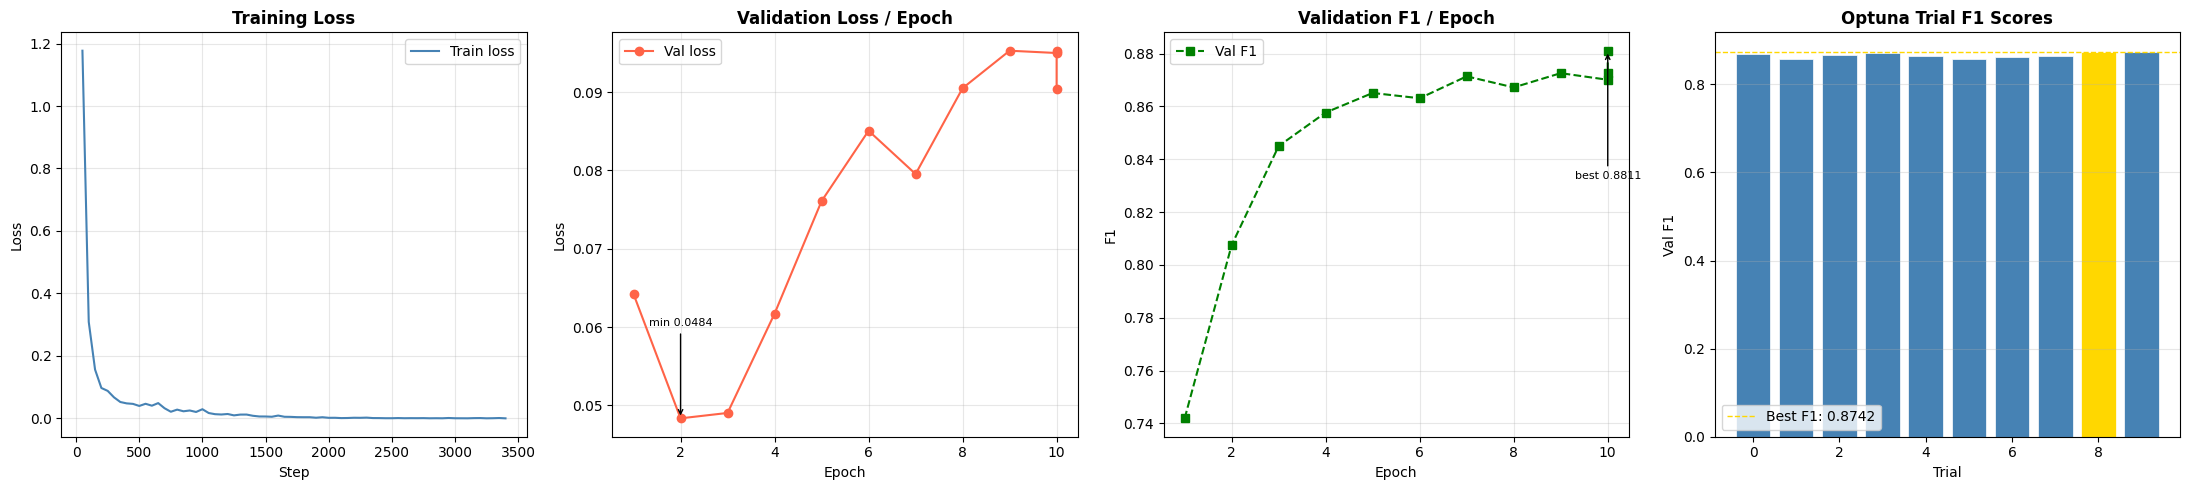

Plots saved to Drive ✅  →  /content/drive/MyDrive/optuna-trial/training_curves.png


In [ ]:
log_history = final_trainer.state.log_history

# Separate train-step logs from epoch-end eval logs cleanly
train_entries = [
    (e["step"], e["loss"])
    for e in log_history
    if "loss" in e and "eval_loss" not in e
]
eval_entries = [
    (e["epoch"], e["eval_loss"], e.get("eval_f1"))
    for e in log_history
    if "eval_loss" in e
]

steps       = [e[0] for e in train_entries]
train_loss  = [e[1] for e in train_entries]
eval_epochs = [e[0] for e in eval_entries]
eval_loss   = [e[1] for e in eval_entries]

eval_f1_pairs = [(ep, f1) for ep, _, f1 in eval_entries if f1 is not None]
f1_epochs     = [p[0] for p in eval_f1_pairs]
f1_vals       = [p[1] for p in eval_f1_pairs]

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

# ── Plot 1: Training loss ──────────────────────────────────────────
ax = axes[0]
if steps:
    ax.plot(steps, train_loss, color="steelblue", linewidth=1.5, label="Train loss")
ax.set_title("Training Loss", fontsize=12, fontweight="bold")
ax.set_xlabel("Step"); ax.set_ylabel("Loss")
ax.grid(True, alpha=0.3); ax.legend()

# ── Plot 2: Validation loss ────────────────────────────────────────
ax = axes[1]
if eval_epochs:
    ax.plot(eval_epochs, eval_loss, "o-", color="tomato", linewidth=1.5, label="Val loss")
    min_idx  = eval_loss.index(min(eval_loss))
    y_range  = max(eval_loss) - min(eval_loss) or 0.05
    ax.annotate(
        f"min {eval_loss[min_idx]:.4f}",
        xy=(eval_epochs[min_idx], eval_loss[min_idx]),
        xytext=(eval_epochs[min_idx], eval_loss[min_idx] + y_range * 0.25),
        arrowprops=dict(arrowstyle="->", color="black"),
        fontsize=8, ha="center"
    )
ax.set_title("Validation Loss / Epoch", fontsize=12, fontweight="bold")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.grid(True, alpha=0.3); ax.legend()

# ── Plot 3: Validation F1 ──────────────────────────────────────────
ax = axes[2]
if f1_vals:
    ax.plot(f1_epochs, f1_vals, "s--", color="green", linewidth=1.5, label="Val F1")
    max_idx = f1_vals.index(max(f1_vals))
    y_range = max(f1_vals) - min(f1_vals) or 0.05
    ax.annotate(
        f"best {f1_vals[max_idx]:.4f}",
        xy=(f1_epochs[max_idx], f1_vals[max_idx]),
        xytext=(f1_epochs[max_idx], f1_vals[max_idx] - y_range * 0.35),
        arrowprops=dict(arrowstyle="->", color="black"),
        fontsize=8, ha="center"
    )
    last_epoch = final_trainer.state.epoch
    if int(last_epoch) < best["epochs"]:
        ax.axvline(x=last_epoch, color="orange", linestyle=":", linewidth=1.5,
                   label=f"Early stop (ep {int(last_epoch)})")
ax.set_title("Validation F1 / Epoch", fontsize=12, fontweight="bold")
ax.set_xlabel("Epoch"); ax.set_ylabel("F1")
ax.grid(True, alpha=0.3); ax.legend()

# ── Plot 4: Optuna trial F1 scores ────────────────────────────────
ax = axes[3]
if optuna_log:
    trial_nums = [t["trial"] for t in optuna_log]
    trial_f1s  = [t["val_f1"] for t in optuna_log]
    best_f1    = max(trial_f1s)
    colors     = ["gold" if f == best_f1 else "steelblue" for f in trial_f1s]
    ax.bar(trial_nums, trial_f1s, color=colors, edgecolor="white", linewidth=0.5)
    ax.axhline(y=best_f1, color="gold", linestyle="--", linewidth=1,
               label=f"Best F1: {best_f1:.4f}")
    ax.set_xlabel("Trial"); ax.set_ylabel("Val F1")
ax.set_title("Optuna Trial F1 Scores", fontsize=12, fontweight="bold")
ax.grid(True, alpha=0.3, axis="y"); ax.legend()

plt.tight_layout()
plot_path = "/content/drive/MyDrive/optuna-trial/training_curves.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Plots saved to Drive ✅  →  {plot_path}")
